# **MINOR PROJECT: Real-World Statistics Project**

**Title:** Customer Behavior Analysis & Business Decision Making

**SECTION 1: Data Understanding**

In [ ]:
# Load dataset.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Mall_Customers.csv")


In [ ]:
# Display: Shape and Columns.

df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
# Check: Missing values and Data types.

df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


Questions:

● What type of dataset is this?

A: This is a **Customer Transaction/Demographic Dataset** from a mall. It contains information about individual customers, including demographic details (Gender, Age), financial attributes (Annual Income), and a behavioral metric (Spending Score).

● Which features are numerical/categorical?

A: **Numerical Features:**
*   CustomerID (although often used as an identifier, it's numerically represented)
*   Age
*   Annual Income (k$)
*   Spending Score (1-100)

**Categorical Features:**
*   Gender

**SECTION 2: Descriptive Analysis**

In [ ]:
# Compute the Mean, Median, and Standard deviation for:
# AGE

mean_age = df['Age'].mean()
median_age = df['Age'].median()
std_dev_age = df['Age'].std()

In [ ]:
# Annual Income

mean_income = df['Annual Income (k$)'].mean()
median_income = df['Annual Income (k$)'].median()
std_dev_income = df['Annual Income (k$)'].std()

In [ ]:
# Spending Score

mean_spending_score = df['Spending Score (1-100)'].mean()
median_spending_score = df['Spending Score (1-100)'].median()
std_dev_spending_score = df['Spending Score (1-100)'].std()

Questions:

● Which feature shows highest variability?

A: Based on the standard deviations:
*   Age: `13.97`
*   Annual Income (k$): `26.26`
*   Spending Score (1-100): `25.82`

The **Annual Income (k$)** feature shows the highest variability.

● Are customers similar or diverse?

A: Customers appear to be **diverse**, particularly in their 'Annual Income (k$)' and 'Spending Score (1-100)', as indicated by the relatively high standard deviations for these features. While age has a lower standard deviation, the overall spread in income and spending suggests a varied customer base.

**SECTION 3: Visualization**

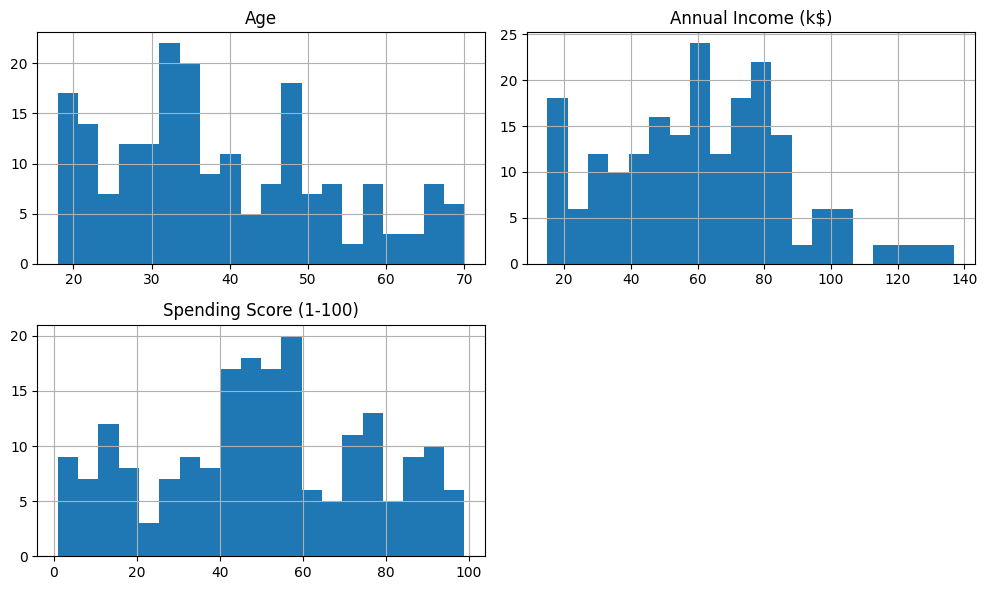

In [ ]:
# Histogram: (Age, Income, Spending)

df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

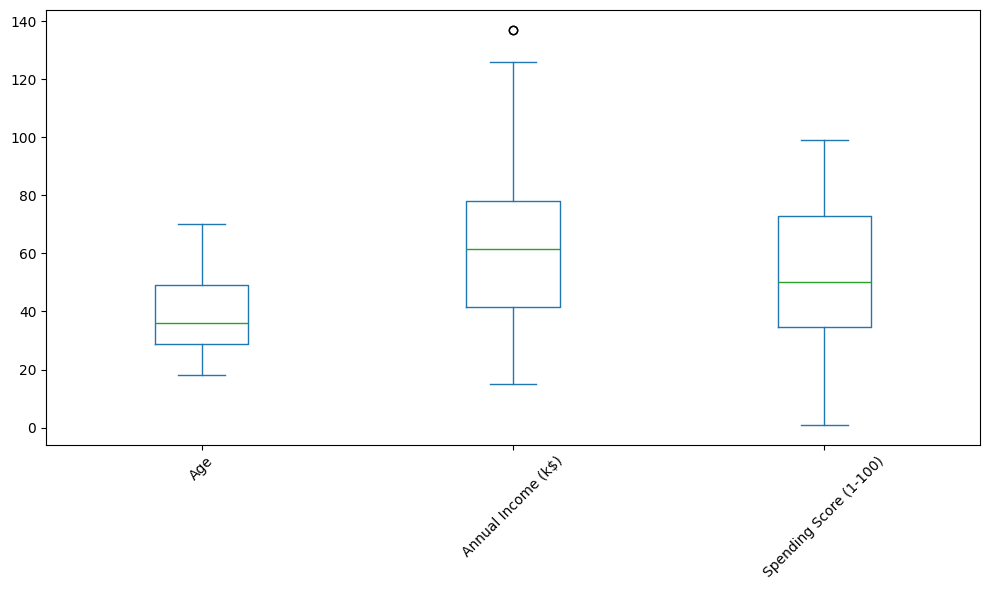

In [ ]:
# Boxplot: (Detect outliers)

df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].plot(kind='box', figsize=(10, 6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Questions:

● Is data skewed?

A: Based on the histograms:
*   **Age:** Appears relatively symmetrical, slightly skewed right.
*   **Annual Income (k$):** Appears relatively symmetrical, slightly skewed right.
*   **Spending Score (1-100):** Shows a fairly uniform distribution, possibly bimodal, rather than a strong skew.

Overall, the data is not strongly skewed, but 'Age' and 'Annual Income' show a mild right skew.

● Are there extreme customers?

A: Based on the boxplots:
*   **Age:** No significant outliers.
*   A**nnual Income (k$):** There are a few data points that could be considered outliers on the higher end of annual income.
*   **Spending Score (1-100):** No significant outliers.

So, there are some 'extreme customers' primarily in terms of their high annual income, but not noticeably for age or spending score.



**SECTION 4: Group-Based Analysis**

In [ ]:
# Compare Male vs Female customers by computing
# Average spending score

df.groupby('Gender')['Spending Score (1-100)'].mean()

,Spending Score (1-100)
Gender,
Female,51.526786
Male,48.511364


In [ ]:
# Average income

df.groupby('Gender')['Annual Income (k$)'].mean()

,Annual Income (k$)
Gender,
Female,59.250000
Male,62.227273


Questions:

● Which group spends more?

A: Based on the average spending score:
*   Female: 51.53
*   Male: 48.51

**Female customers, on average, spend slightly more.**

● Is there a visible difference?

A: There is a visible, albeit small, difference in both average spending score and average annual income between genders.

*   **Spending Score:** Females have a slightly higher average spending score.
*   **Annual Income:** Males have a slightly higher average annual income (`62.23 k$`) compared to females (`59.25 k$`).

**SECTION 5: Correlation Analysis**

In [ ]:
# Identify correlation between:
# Income vs Spending Score

correlation_income_spending = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
correlation_income_spending

np.float64(0.009902848094037608)

In [ ]:
# Age vs Spending Score

correlation_age_spending = df['Age'].corr(df['Spending Score (1-100)'])
correlation_age_spending

np.float64(-0.32722684603909014)

Questions:

● Do richer customers spend more?

A: The correlation coefficient between 'Annual Income (k$)' and 'Spending Score (1-100)' is approximately `0.01`. This is a very weak positive correlation, suggesting that there is **no significant linear relationship** between a customer's income and their spending score. Therefore, richer customers do not necessarily spend more.

● Does age affect spending?

A: The correlation coefficient between 'Age' and 'Spending Score (1-100)' is approximately `-0.33`. This indicates a **weak negative linear relationship**. As age increases, the spending score tends to slightly decrease, but the relationship is not very strong.

**SECTION 6: Inferential Statistics (CORE)**

**Problem Statement:** “Do male and female customers spend differently?”

**Step 1: Hypothesis**

$H_0$: No difference in spending.

$H_1$: There is a difference.

**Step 2: Perform Test**

In [ ]:
from scipy import stats
male = df[df['Gender'] == 'Male']['Spending Score (1-100)']
female = df[df['Gender'] == 'Female']['Spending Score (1-100)']
t_stat, p_value = stats.ttest_ind(male, female)

**Step 3: Decision**

If $p < 0.05 \rightarrow$ Reject $H_0$

 **Step 4: Conclusion**

The calculated p-value is `0.4137`.

Since $p \text{ (0.4137)} \not< 0.05$, we **fail to reject the null hypothesis** ($H_0$).

**Interpretation:** There is no statistically significant evidence to conclude that male and female customers spend differently.

Questions:

● What does p-value tell you?

A: The **p-value** is the probability of observing a test statistic (like our t-statistic) as extreme as, or more extreme than, the one calculated from our data, *assuming the null hypothesis is true*. A small p-value suggests that our observed data is unlikely under the null hypothesis, leading us to question its validity.

● Is the difference statistically significant?

A: With a p-value of `0.4137`, which is much greater than the commonly used significance level of `0.05`, the difference in spending scores between male and female customers is **not statistically significant**. This means we do not have enough evidence to conclude that there's a real difference in spending habits between the genders in this dataset.

**SECTION 7: Confidence Interval**

In [ ]:
# Calculate 95% CI for the Spending Score.

import scipy.stats as stats

spending_scores = df['Spending Score (1-100)']
print("95% Confidence Interval for Spending Score:")
print(stats.t.interval(0.95, len(spending_scores)-1, loc=np.mean(spending_scores), scale=stats.sem(spending_scores)))

95% Confidence Interval for Spending Score:
(np.float64(46.5992098573812), np.float64(53.80079014261881))


Questions:

● What range do customers fall into?

A: The 95% Confidence Interval for the Spending Score is approximately `(46.60, 53.80)`. This means that we are 95% confident that the true average spending score for all customers in the mall population lies within this range.

● How confident are we?

A: We are **95% confident** that the true population mean of the Spending Score falls within the calculated interval. This level of confidence is commonly used in statistical analysis.

**SECTION 8: Business Insights**

1. Which customers should the business target?

A: Based on the analysis, the business should consider targeting:

*   High-Spending Customers (Spending Score 1-100)

*   Younger Customers

*   All Genders Equitably

*   High-Income Customers

2. Does income affect spending?

A: Based on the correlation analysis in **SECTION 5**, the correlation coefficient between 'Annual Income (k$)' and 'Spending Score (1-100)' was found to be approximately `0.01`. This indicates a **very weak positive linear relationship**, which is practically negligible.

Therefore, we can conclude that, according to this dataset, **annual income does not significantly affect spending score in a linear fashion**. Richer customers do not necessarily exhibit higher spending scores in a predictable manner.

3. Should marketing differ by gender?

A: Based on the independent samples t-test conducted in SECTION 6, the p-value was `0.4137`. Since this p-value is greater than the common significance level of `0.05`, we failed to reject the null hypothesis. This means there is no statistically significant evidence to conclude that male and female customers spend differently.

Therefore, marketing strategies do not necessarily need to differ significantly by gender based solely on spending score. While there was a slight numerical difference in average spending (Female: 51.53, Male: 48.51) and income (Male: `62.23 k$`, Female: `59.25 k$`), these differences were not found to be statistically significant. Marketing efforts should focus on other segmentation variables where significant differences were found or could be explored rather than gender.

4. What strategy would you suggest?

A: Based on the comprehensive analysis, here is a suggested strategy:

1.  Develop a Segmentation Strategy Focused on Spending Behavior:
    - Create targeted campaigns for High Spenders (e.g., loyalty programs, exclusive offers, early access to new products). For Medium Spenders, focus on increasing their engagement and average transaction value through personalized recommendations.

2.  Target Younger Demographics with Relevant Offers:
     - Design marketing campaigns and product assortments that appeal to younger age groups. Utilize channels popular with this demographic (e.g., social media, influencers).

3.  Gender-Neutral Marketing Approach:
    - Focus on universal appeals, product benefits, and lifestyle messaging that resonates across all genders. Personalization should be based on individual preferences and spending habits rather than gender.

4.  Focus on Customer Engagement and Experience:
    - Implement strategies to enhance the overall customer experience, encourage repeat visits, and gather more granular data on purchasing behaviors to refine future segmentation and targeting efforts.